<a href="https://colab.research.google.com/github/Kisara10/Match-prediction--ML-/blob/prediction-code/Match_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libarires
import pandas as pd
import numpy as np

In [2]:
# Get the file and display first five rows
df = pd.read_csv("/content/ODI_cricinfo.csv")
df.head()

,Scorecard,Team 1,Team 2,Winner,Margin,Ground,Match Date
0,ODI # 1,Australia,England,Australia,5 wickets,Melbourne,"Jan 5, 1971"
1,ODI # 2,England,Australia,England,6 wickets,Manchester,"Aug 24, 1972"
2,ODI # 3,England,Australia,Australia,5 wickets,Lord's,"Aug 26, 1972"
3,ODI # 4,England,Australia,England,2 wickets,Birmingham,"Aug 28, 1972"
4,ODI # 5,New Zealand,Pakistan,New Zealand,22 runs,Christchurch,"Feb 11, 1973"


In [3]:
# Check the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4124 entries, 0 to 4123
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Scorecard   4124 non-null   object
 1   Team 1      4124 non-null   object
 2   Team 2      4124 non-null   object
 3   Winner      4124 non-null   object
 4   Margin      3938 non-null   object
 5   Ground      4124 non-null   object
 6   Match Date  4124 non-null   object
dtypes: object(7)
memory usage: 225.7+ KB


In [4]:
df.describe()

,Scorecard,Team 1,Team 2,Winner,Margin,Ground,Match Date
count,4124,4124,4124,4124,3938,4124,4124
unique,4124,25,26,26,235,176,3540
top,ODI # 4124,Australia,Pakistan,Australia,6 wickets,Sharjah,"Feb 4, 2007"
freq,1,599,530,566,360,238,6


In [5]:
# Number of rows and columns
df.shape

(4124, 7)

In [6]:
# Check missing data values
df.isnull().sum()

,0
Scorecard,0
Team 1,0
Team 2,0
Winner,0
Margin,186
Ground,0
Match Date,0


In [7]:
# Remove the "Margin" column
df.drop(['Margin', 'Scorecard'], axis=1, inplace=True)
df.head()

,Team 1,Team 2,Winner,Ground,Match Date
0,Australia,England,Australia,Melbourne,"Jan 5, 1971"
1,England,Australia,England,Manchester,"Aug 24, 1972"
2,England,Australia,Australia,Lord's,"Aug 26, 1972"
3,England,Australia,England,Birmingham,"Aug 28, 1972"
4,New Zealand,Pakistan,New Zealand,Christchurch,"Feb 11, 1973"


In [8]:
# Select the features and targets
X = df[['Team 1', 'Team 2', 'Ground']]
y = df['Winner']

In [9]:
# Convert the labels into numbers
from sklearn.preprocessing import LabelEncoder

team1_encoder = LabelEncoder()
team2_encoder = LabelEncoder()
ground_encoder = LabelEncoder()
winner_encoder = LabelEncoder()

df['Team 1'] = team1_encoder.fit_transform(df['Team 1'])
df['Team 2'] = team2_encoder.fit_transform(df['Team 2'])
df['Ground'] = ground_encoder.fit_transform(df['Ground'])
df['Winner'] = winner_encoder.fit_transform(df['Winner'])

df.head()

,Team 1,Team 2,Winner,Ground,Match Date
0,3,7,3,103,"Jan 5, 1971"
1,8,2,7,101,"Aug 24, 1972"
2,8,2,3,98,"Aug 26, 1972"
3,8,2,7,16,"Aug 28, 1972"
4,16,18,15,36,"Feb 11, 1973"


In [10]:
# Split into training and testing data
from sklearn.model_selection import train_test_split

X = df[['Team 1', 'Team 2', 'Ground']]
y = df['Winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
df.head()

,Team 1,Team 2,Winner,Ground,Match Date
0,3,7,3,103,"Jan 5, 1971"
1,8,2,7,101,"Aug 24, 1972"
2,8,2,3,98,"Aug 26, 1972"
3,8,2,7,16,"Aug 28, 1972"
4,16,18,15,36,"Feb 11, 1973"


In [12]:
# Save the prepared dataset

df.to_csv(r'/content/Prepared_match_data.csv', index= False)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

Classification report for LR
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.40      0.78      0.53       120
           4       0.00      0.00      0.00        22
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00        74
          10       0.13      0.24      0.17       104
          11       0.00      0.00      0.00        11
          12       0.00      0.00      0.00         5
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00        76
          16       0.00      0.00      0.00         1
          17       0.14      0.31      0.19        78
          18       0.00      0.00      0.00         

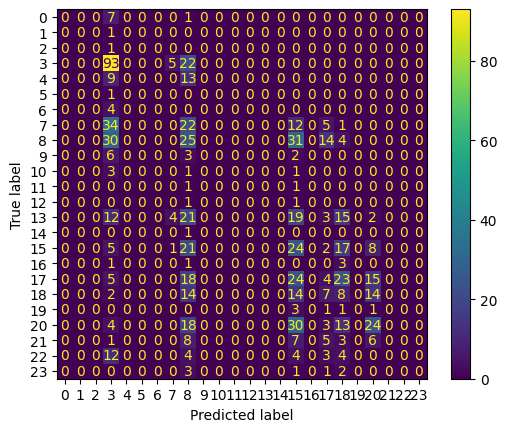

In [14]:
# Train the LR model
lr = LogisticRegression(max_iter=2000)
lr = lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Generate a classification and confusion matrix
print("Classification report for LR")
print(classification_report(y_test, y_pred_lr))

print("Confusion_matrix for LR")
lr_cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm)
disp.plot()

In [15]:
# DT model
dt = DecisionTreeClassifier()
dt=dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

from sklearn.metrics import classification_report
print("Classification report for DT")
print(classification_report(y_test,y_pred_dt))

Classification report for DT
              precision    recall  f1-score   support

           0       0.50      0.88      0.64         8
           1       0.00      0.00      0.00         1
           2       0.50      1.00      0.67         1
           3       0.63      0.77      0.69       120
           4       0.56      0.68      0.61        22
           5       0.50      1.00      0.67         1
           6       0.67      0.50      0.57         4
           7       0.48      0.64      0.55        74
           8       0.00      0.00      0.00         0
          10       0.52      0.62      0.57       104
          11       0.80      0.36      0.50        11
          12       1.00      0.60      0.75         5
          13       1.00      0.50      0.67         2
          14       0.33      0.50      0.40         2
          15       0.55      0.46      0.50        76
          16       0.00      0.00      0.00         1
          17       0.59      0.58      0.58        7

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [16]:
# build the KNN model
kn = KNeighborsClassifier(n_neighbors=9)
kn.fit(X_train, y_train)

y_pred_kn = kn.predict(X_test)
print("Classification report for KNN")
print(classification_report(y_test,y_pred_kn))

Classification report for KNN
              precision    recall  f1-score   support

           0       0.38      0.62      0.48         8
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.51      0.62      0.56       120
           4       0.48      0.45      0.47        22
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         4
           7       0.36      0.62      0.45        74
           8       0.00      0.00      0.00         0
          10       0.41      0.53      0.46       104
          11       0.29      0.18      0.22        11
          12       0.14      0.20      0.17         5
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         2
          15       0.52      0.41      0.46        76
          16       0.00      0.00      0.00         1
          17       0.43      0.47      0.45        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [17]:
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_kn))

LR Accuracy: 0.21575757575757576
DT Accuracy: 0.5515151515151515
KNN Accuracy: 0.42303030303030303


In [18]:
final_model = dt

In [19]:
def predict_match(team1, team2, ground):
    team1 = team1_encoder.transform([team1])[0]
    team2 = team2_encoder.transform([team2])[0]
    ground = ground_encoder.transform([ground])[0]

    input_data = [[team1, team2, ground]]
    prediction = final_model.predict(input_data)
    winner = winner_encoder.inverse_transform(prediction)[0]
    return winner

In [20]:
import pickle

pickle.dump(final_model, open("cricket_match_predictor.pkl", "wb"))
pickle.dump(winner_encoder, open("winner_encoder.pkl","wb"))
pickle.dump(team1_encoder, open("team1_encoder.pkl","wb"))
pickle.dump(team2_encoder, open("team2_encoder.pkl","wb"))
pickle.dump(ground_encoder, open("ground_encoder.pkl","wb"))

Model Comparison Results:

Logistic Regression Accuracy: 21.6%
Decision Tree Accuracy: 54.9%
KNN Accuracy: 42.3%

Decision Tree achieved the highest accuracy and was selected as the final model for predicting cricket match winners.